# 05 · Model evaluation

Benchmark comparison, per-class analysis, calibration and out-of-distribution
behaviour - all read from the experiment ledger.


In [1]:
# Make the project's own modules importable, and apply the OpenMP fix that must
# run before torch is imported.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "backend"))
sys.path.insert(0, str(PROJECT_ROOT / "training"))

import app.core.runtime  # noqa: F401  (sets OMP env before numpy/torch)

import json
import numpy as np
import matplotlib.pyplot as plt

from app.core.config import settings

print("Project root:", PROJECT_ROOT)


Project root: D:\Data science projects\Plant disease detection


## The benchmark table

In [2]:
import pandas as pd

ledger = json.loads((settings.results_dir / "experiments.json").read_text(encoding="utf-8"))

def flatten(record):
    test = record.get("test") or {}
    metrics = test.get("metrics") or {}
    return {
        "model": record.get("label"),
        "group": record.get("group"),
        "protocol": record.get("protocol"),
        "proposed": record.get("proposed"),
        "accuracy": metrics.get("accuracy"),
        "macro_f1": metrics.get("f1_macro"),
        "top3": metrics.get("top3_accuracy"),
        "params_M": (record.get("total_parameters") or 0) / 1e6,
        "size_MB": record.get("model_size_mb"),
        "ms_per_image": (test.get("latency") or {}).get("single_image_ms"),
        "ece": (test.get("calibration") or {}).get("ece"),
    }

frame = pd.DataFrame([flatten(r) for r in ledger if (r.get("test") or {}).get("metrics")])
frame.sort_values("accuracy", ascending=False).round(4)


,model,group,protocol,proposed,accuracy,macro_f1,top3,params_M,size_MB,ms_per_image,ece
8,ResNet50 + CBAM,benchmark,benchmark,False,0.9914,0.9914,0.9996,24.1103,92.1765,15.9278,0.0612
5,ResNet50,benchmark,benchmark,False,0.9912,0.9912,0.9993,23.5859,90.1761,14.1925,0.0614
26,EfficientNet-B0,benchmark,production,False,0.9906,0.9904,0.9994,4.0562,15.6339,18.5029,0.0500
25,EfficientNet-B0 + CBAM,benchmark,production,True,0.9900,0.9898,0.9994,4.2611,16.4156,13.1698,0.0500
24,Custom CNN + CBAM,benchmark,production,True,0.9842,0.9842,0.9990,1.2602,4.8146,7.4109,0.0245
6,DenseNet121,benchmark,benchmark,False,0.9781,0.9780,0.9978,6.9928,26.9955,33.5226,0.0617
3,EfficientNet-B0,benchmark,benchmark,False,0.9702,0.9700,0.9965,4.0562,15.6339,19.4663,0.0721
7,EfficientNet-B0 + CBAM,benchmark,benchmark,True,0.9682,0.9681,0.9963,4.2611,16.4156,17.8426,0.0727
17,CBAM on last two stages,placement,placement,False,0.9678,0.9676,0.9969,1.2592,4.8109,5.7021,0.0429
18,CBAM on every stage,placement,placement,False,0.9654,0.9652,0.9967,1.2602,4.8146,4.5830,0.0472


## Accuracy against cost

The interesting question is not which model wins, but what the win costs.

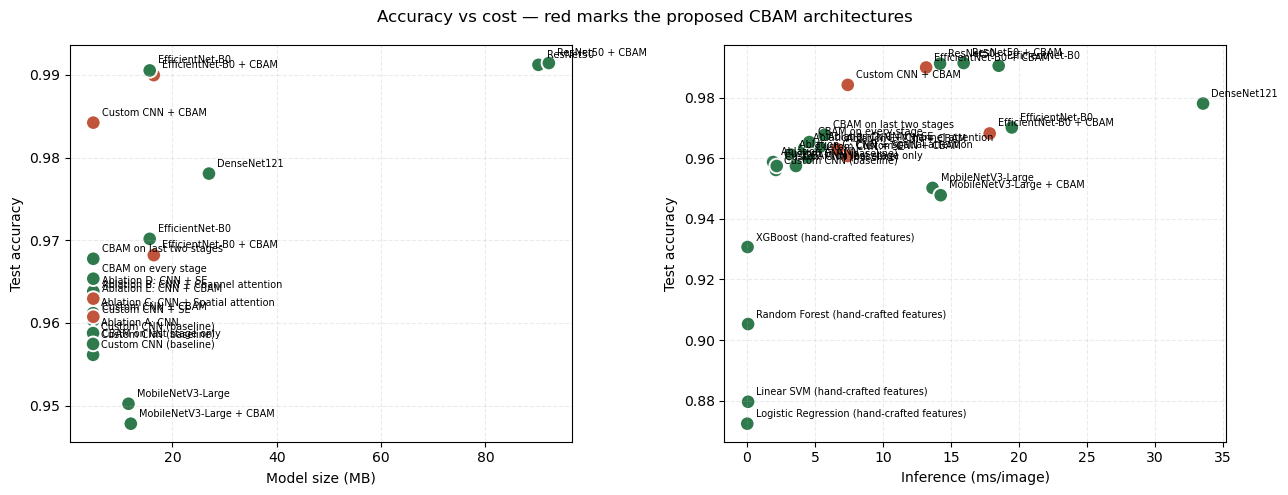

In [3]:
fig, (ax_size, ax_speed) = plt.subplots(1, 2, figsize=(13, 5))
for ax, key, label in ((ax_size, "size_MB", "Model size (MB)"),
                       (ax_speed, "ms_per_image", "Inference (ms/image)")):
    subset = frame.dropna(subset=[key, "accuracy"])
    colors = ["#c1553b" if p else "#2f7a4d" for p in subset["proposed"]]
    ax.scatter(subset[key], subset["accuracy"], s=110, c=colors, edgecolor="white", linewidth=1.4)
    for _, row in subset.iterrows():
        ax.annotate(row["model"], (row[key], row["accuracy"]), fontsize=7,
                    xytext=(6, 5), textcoords="offset points")
    ax.set_xlabel(label); ax.set_ylabel("Test accuracy")
    ax.grid(alpha=0.25, linestyle="--")
fig.suptitle("Accuracy vs cost — red marks the proposed CBAM architectures")
plt.tight_layout(); plt.show()


## Per-class performance

The classes the model finds hardest are where more data would help most.

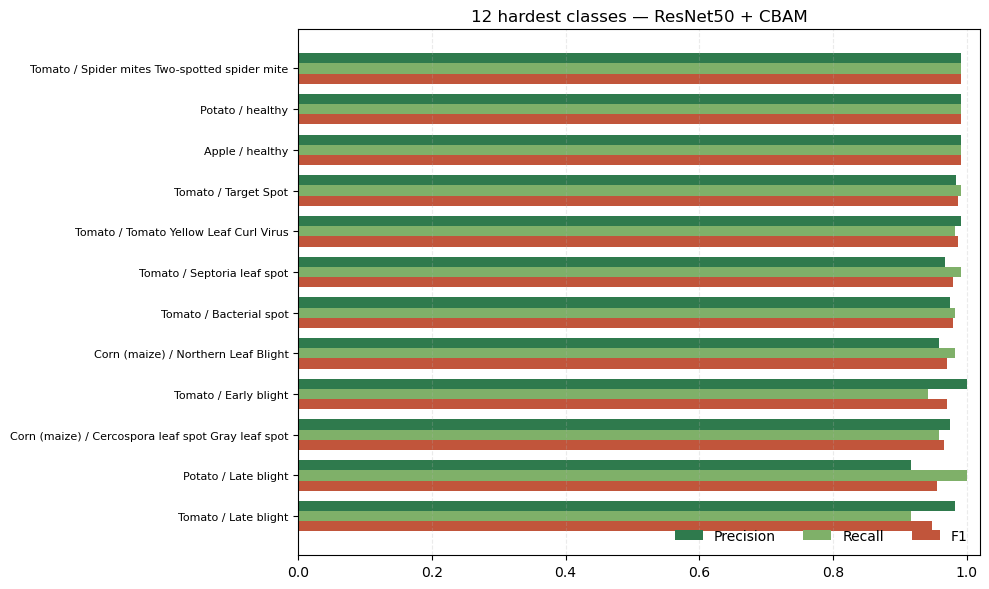

In [4]:
best = max((r for r in ledger if (r.get("test") or {}).get("metrics")),
           key=lambda r: r["test"]["metrics"]["accuracy"])
per_class = best["test"]["metrics"]["per_class"]

rows = sorted(per_class.items(), key=lambda kv: kv[1]["f1"])[:12]
names = [k.replace("___", " / ").replace("_", " ") for k, _ in rows]
y = np.arange(len(names))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y + 0.25, [v["precision"] for _, v in rows], 0.25, label="Precision", color="#2f7a4d")
ax.barh(y,        [v["recall"]    for _, v in rows], 0.25, label="Recall",    color="#7fb069")
ax.barh(y - 0.25, [v["f1"]        for _, v in rows], 0.25, label="F1",        color="#c1553b")
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=8)
ax.set_xlim(0, 1.02); ax.legend(frameon=False, ncol=3, loc="lower right")
ax.set_title(f"12 hardest classes — {best['label']}")
ax.grid(axis="x", alpha=0.25, linestyle="--")
plt.tight_layout(); plt.show()


## Confidence calibration

Temperature scaling divides the logits by one scalar fitted on the validation
split. It cannot change which class wins, so accuracy is unchanged by
construction — only the confidence values move.


ECE  raw 0.0612   scaled 0.0022
MCE  raw 0.8315   temperature T = 0.6035
Mean confidence 0.9305 vs accuracy 0.9914


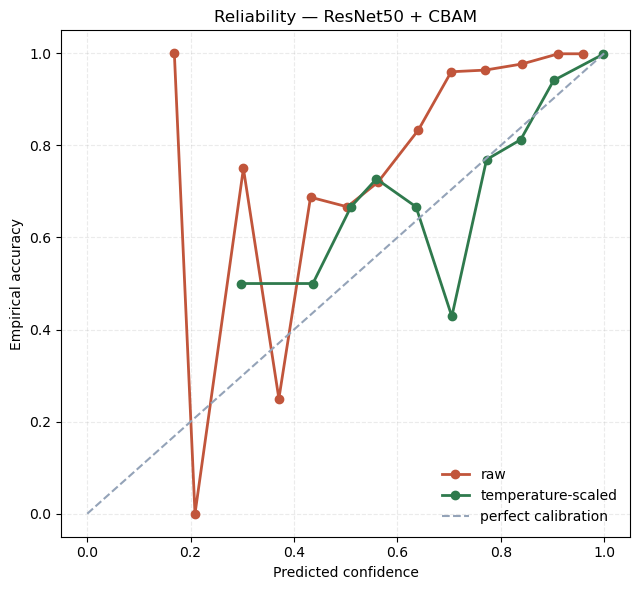

In [5]:
calibration = best["test"].get("calibration")
if calibration:
    print(f"ECE  raw {calibration['ece']:.4f}   scaled {calibration['after_temperature']['ece']:.4f}")
    print(f"MCE  raw {calibration['mce']:.4f}   temperature T = {calibration['temperature']:.4f}")
    print(f"Mean confidence {calibration['mean_confidence']:.4f} vs accuracy {calibration['accuracy']:.4f}")

    fig, ax = plt.subplots(figsize=(6.5, 6))
    for bins, label, color in ((calibration["bins"], "raw", "#c1553b"),
                               (calibration["after_temperature"]["bins"], "temperature-scaled", "#2f7a4d")):
        points = [(b["confidence"], b["accuracy"]) for b in bins if b["count"] > 0]
        ax.plot([p[0] for p in points], [p[1] for p in points], "o-", label=label, color=color, lw=2)
    ax.plot([0, 1], [0, 1], "--", color="#94a3b8", label="perfect calibration")
    ax.set_xlabel("Predicted confidence"); ax.set_ylabel("Empirical accuracy")
    ax.set_title(f"Reliability — {best['label']}"); ax.legend(frameon=False)
    ax.grid(alpha=0.25, linestyle="--")
    plt.tight_layout(); plt.show()


## Out-of-distribution behaviour

The stand-alone scores are weak — that is a known property of softmax-based OOD
detection, not a bug here. It is why the image-quality gate runs first, and why
the number that matters is the whole-pipeline rate.


In [6]:
path = settings.metadata_dir / "ood_thresholds.json"
if path.exists():
    ood = json.loads(path.read_text(encoding="utf-8"))
    print("AUROC by score:")
    for name, value in ood["metrics"]["auroc"].items():
        print(f"  {name:<28}{value:.4f}")

    pipeline = ood["metrics"].get("pipeline")
    if pipeline:
        print("\nWhole-pipeline rejection:")
        print(f"  quality gate alone      {pipeline['quality_gate_rejects_ood'] * 100:5.1f}%")
        print(f"  OOD score alone         {pipeline['ood_score_rejects_ood'] * 100:5.1f}%")
        print(f"  combined                {pipeline['pipeline_rejects_ood'] * 100:5.1f}%")
        print(f"  cost (real leaves lost) {pipeline['quality_gate_rejects_real_leaves'] * 100:5.1f}%")
    print("\nCaveat:", ood["ood_source"].get("caveat", ""))
else:
    print("Run `python training/calibrate_ood.py` first.")


AUROC by score:
  Max softmax probability     0.9752
  Normalised entropy          0.9770
  Free energy                 0.9415

Whole-pipeline rejection:
  quality gate alone       63.0%
  OOD score alone          93.5%
  combined                 95.0%
  cost (real leaves lost)   2.0%

Caveat: Synthetic proxies (uniform noise, flat colour fields, tile-shuffled leaves, heavily degraded leaves) are genuinely out of distribution but are easier to reject than real photographs of unrelated subjects. The detection rates below are therefore an upper bound. Re-run with --ood-dir pointing at a real non-leaf corpus for a tighter estimate.


## Explainability on real predictions

In [7]:
import torch
from PIL import Image
from app.ml.datasets import read_manifest
from app.ml.explain import grad_cam, grad_cam_plus_plus, overlay_heatmap
from app.ml.transforms import build_eval_transform, resized_rgb
from evaluate import load_checkpoint

manifest_path = settings.exported_dir / "production.json"
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    model, config, class_names = load_checkpoint(
        PROJECT_ROOT / manifest["checkpoint"], torch.device("cpu"))
    rows = read_manifest(settings.data_dir / "manifests" / "test_bench.csv")

    fig, axes = plt.subplots(3, 4, figsize=(13, 10))
    for column, row in enumerate(rows[::900][:4]):
        with Image.open(row.path) as handle:
            image = handle.convert("RGB")
        tensor = build_eval_transform(config.image_size)(image).unsqueeze(0)
        base = np.asarray(resized_rgb(image, config.image_size))

        with torch.no_grad():
            probs = torch.softmax(model(tensor)[0], dim=0)
        top = int(probs.argmax())

        axes[0, column].imshow(base)
        axes[0, column].set_title(f"{class_names[top].split('___')[-1][:22]}\n{probs[top]:.1%}", fontsize=8)
        axes[1, column].imshow(overlay_heatmap(base, grad_cam(model, tensor, model.feature_layer).heatmap))
        axes[1, column].set_title("Grad-CAM", fontsize=8)
        axes[2, column].imshow(overlay_heatmap(base, grad_cam_plus_plus(model, tensor, model.feature_layer).heatmap))
        axes[2, column].set_title("Grad-CAM++", fontsize=8)
        for r in range(3):
            axes[r, column].axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Run `python training/export_model.py` first.")


C:\Users\ayush\AppData\Local\Temp\ipykernel_13240\3167968866.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


> **Reading heat maps honestly.** These show where the network pooled evidence
> for its decision, at the resolution of its final feature map. They are **not**
> a disease segmentation and do not measure lesion extent. Their real diagnostic
> value is negative evidence: if the bright region sits on the background rather
> than the leaf, the model has latched onto a spurious correlation and the
> prediction should be distrusted however confident it is.
